In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
import math
import random
import importlib

import seaborn as sns
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import roc_auc_score, f1_score

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

## Panel e — observed variant, averaged over 5 independent runs

Adapted from `norman_run.md`. Reruns the exact
model + GEARS pipeline that produces panel e ("Per-class AUC-ROC" /
"Summary metrics"), using observed=True and trained on all data.

## Load Norman 2019 data


In [3]:
data = sc.read_h5ad("../Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering


In [4]:
import scipy.sparse as sp

# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# Norman 2019: use all genes with mean expression > 0.5 UMI per cell (~2800 genes).
raw_X = data.X
mean_expr = np.array(raw_X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5

# Always keep perturbation target genes so their expression is available.
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

n_expr      = int(expr_mask[keep_mask].sum())
n_pert_only = int((pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum())
print(f"Kept {data.n_vars} genes  ({n_expr} with mean > 0.5 UMI + {n_pert_only} pert-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

Kept 3270 genes  (3190 with mean > 0.5 UMI + 80 pert-only)
Pert genes in var_names: 102 / 105


## Compute treatment effects


In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations x {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|████████████████████████████████████████████████████████████████████████| 236/236 [00:07<00:00, 32.63it/s]

treat_effect: 236 perturbations x 3270 genes
  single: 105   combo: 131


## Device


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## GI ground truth + eval helpers

Same helper functions as `norman_run.md`'s panel-e cell — copied once, used
inside the loop below for every run.


In [7]:
def canon(s):
    a, b = s.split('+')
    return '+'.join(sorted([a, b]))


def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))


def gi_combinations(df):
    if "combination" in df.columns:
        return df["combination"].astype(str).map(canon_pair)
    if {"pert_a", "pert_b"}.issubset(df.columns):
        return (df["pert_a"].astype(str) + "+" + df["pert_b"].astype(str)).map(canon_pair)
    return pd.Series(df.index.astype(str), index=df.index).map(canon_pair)


def evaluate_gi_predictions(df, model_name, gt):
    work = df.copy()
    combos = gi_combinations(work)
    eval_combinations = set(gt["combination"])
    work = slk.tl.classify_gi(
        work,
        fit_mask=combos.isin(eval_combinations),
        inplace=True,
    )
    work["combination"] = combos
    eval_df = work.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    eval_df = eval_df.loc[eval_df["predicted_gi"].notna()].copy()

    y_true = eval_df["genetic_interaction"].astype(str)
    y_pred = eval_df["predicted_gi"].astype(str)
    labels = sorted(set(y_true.unique()) | set(y_pred.unique()))

    summary = pd.DataFrame([
        {"model": model_name, "metric": "Accuracy", "score": float((y_true == y_pred).mean())},
        {"model": model_name, "metric": "F1 macro", "score": f1_score(y_true, y_pred, average="macro", zero_division=0)},
        {"model": model_name, "metric": "F1 weighted", "score": f1_score(y_true, y_pred, average="weighted", zero_division=0)},
    ])

    auc_rows = []
    for cls in labels:
        true_bin = (y_true == cls).astype(int)
        pred_bin = (y_pred == cls).astype(int)
        n_pos = int(true_bin.sum())
        auc = roc_auc_score(true_bin, pred_bin) if 0 < n_pos < len(true_bin) else np.nan
        auc_rows.append({
            "model": model_name,
            "class": cls,
            "n_positive": n_pos,
            "f1": f1_score(true_bin, pred_bin, zero_division=0),
            "auc_roc": auc,
        })
    return eval_df, pd.DataFrame(auc_rows), summary


gi = pd.read_csv("./genetic_interactions.csv")
gi["combination"] = gi["combination"].map(canon_pair)
gi["genetic_interaction"] = gi["genetic_interaction"].astype(str).str.strip()

## GEARS setup (loaded once, reused every run)


In [ ]:
import sherlock.tools._gears as gears_tools
import sherlock.tools._models as models_tools

importlib.reload(gears_tools)
importlib.reload(models_tools)

slk.tl.classify_gi = models_tools.classify_gi
slk.tl.run_gears_gi = gears_tools.run_gears_gi
slk.tl.train_gears = gears_tools.train_gears
slk.tl.predict_gears_combinations = gears_tools.predict_gears_combinations
slk.tl.get_observed_combinations = gears_tools.get_observed_combinations

gears_combos = slk.tl.get_observed_combinations(
    data,
    pert_key=p_key,
    ntc_label=NTC,
)

## Rerun VAE + GEARS 5x on all data 

In [ ]:
N_RUNS = 5
SEEDS = [42 + i for i in range(N_RUNS)]

RESULTS_DIR = "../results/observed_panel_e"
os.makedirs(RESULTS_DIR, exist_ok=True)

_auc_frames = []
_summary_frames = []

for run_idx, seed in enumerate(SEEDS):
    print(f"\n=== Run {run_idx + 1}/{N_RUNS}  (seed={seed}) ===")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # ---- VAE, trained on ALL data (no held-out val split) ----
    results = slk.tl.run_single(
        data,
        model='vae',
        l0_lambda=25,
        rank=6,
        shuffle=True,
        num_workers=0,
        device=device,
        num_epochs=500,
        validate_every=50,
        patience=15,
        combinatorial=True,
        debug=True,
        n_epochs_l0_warmup=200,
    )
    model = results['model']
    slk.tl.save_results(results, f'{RESULTS_DIR}/norman_all_run{run_idx}.pth')

    slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)

    # NOTE: `observed=True` is a best guess for the real get_gi kwarg name —
    # confirm against your sherlock signature (default is 'hybrid').
    syn = model.get_gi(
        data,
        obsm_key='z',
        min_cells=5,
        observed=True,
    )
    syn.to_csv(f'{RESULTS_DIR}/syn_run{run_idx}.csv', index=True)

    # ---- GEARS, trained fresh on ALL data ----
    gears_run = slk.tl.run_gears_gi(
        data,
        combos=gears_combos,
        data_dir="./gears_data",
        dataset_name="norman_sherlock",
        pert_key=p_key,
        ntc_label=NTC,
        split="all",
        seed=seed,
        force_reprocess=False,
        model_path=f"{RESULTS_DIR}/gears_model_run{run_idx}",
        verbose=True,
        quiet_steps=True,
        device=str(device),
    )
    gears_gi = gears_run.gi
    if gears_gi is not None:
        gears_gi.to_csv(f'{RESULTS_DIR}/gears_gi_run{run_idx}.csv', index=False)

    # ---- Score both models against Norman GT for this run ----
    for _name, _df in [("Sherlock (observed)", syn), ("GEARS", gears_gi)]:
        _eval_df, _auc_df, _summary_df = evaluate_gi_predictions(_df, _name, gi)
        _auc_df["run"] = run_idx
        _summary_df["run"] = run_idx
        _auc_frames.append(_auc_df)
        _summary_frames.append(_summary_df)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

gi_auc_df_all = pd.concat(_auc_frames, ignore_index=True)
gi_summary_df_all = pd.concat(_summary_frames, ignore_index=True)

gi_auc_df_all.to_csv(f'{RESULTS_DIR}/gi_auc_df_all.csv', index=False)
gi_summary_df_all.to_csv(f'{RESULTS_DIR}/gi_summary_df_all.csv', index=False)

print(f"\nCollected {N_RUNS} runs -> {len(gi_auc_df_all)} auc rows, {len(gi_summary_df_all)} summary rows")

## Panel e

In [8]:
RESULTS_DIR = "../results/observed_panel_e"
gi_auc_df_all = pd.read_csv(f'{RESULTS_DIR}/gi_auc_df_all.csv')
gi_summary_df_all = pd.read_csv(f'{RESULTS_DIR}/gi_summary_df_all.csv')

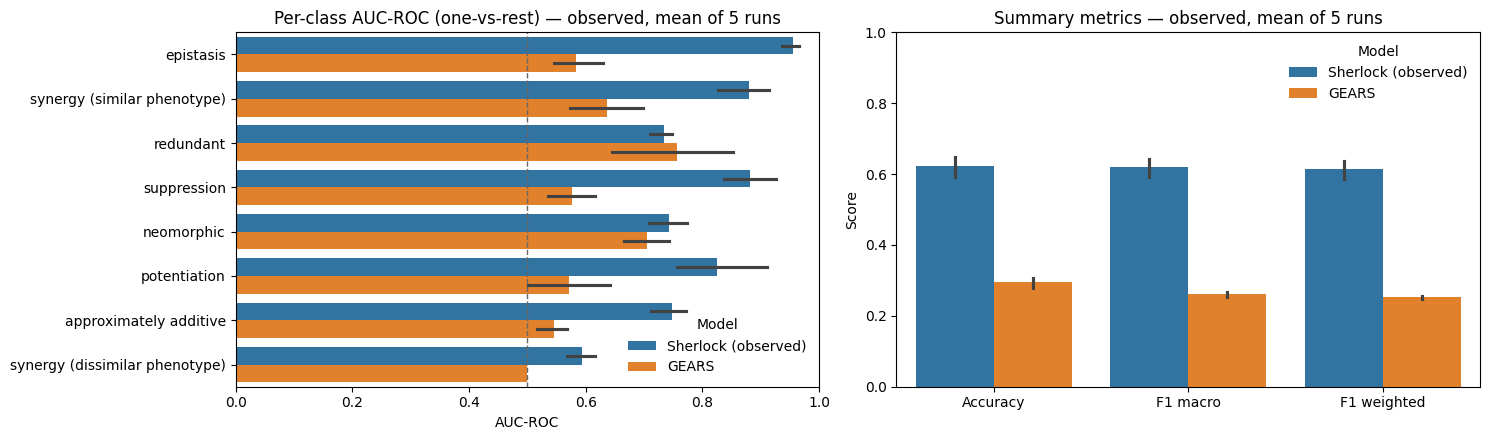

In [9]:
class_order = (
    gi_auc_df_all.groupby("class")["auc_roc"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
metric_order = ["Accuracy", "F1 macro", "F1 weighted"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(
    data=gi_auc_df_all,
    y="class",
    x="auc_roc",
    hue="model",
    order=class_order,
    ax=axes[0],
)
axes[0].axvline(0.5, color="0.4", linestyle="--", linewidth=1)
axes[0].set_xlabel("AUC-ROC")
axes[0].set_ylabel("")
axes[0].set_title("Per-class AUC-ROC (one-vs-rest) — observed, mean of 5 runs")
axes[0].set_xlim(0, 1)
axes[0].legend(title="Model", frameon=False)

sns.barplot(
    data=gi_summary_df_all,
    x="metric",
    y="score",
    hue="model",
    order=metric_order,
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_title("Summary metrics — observed, mean of 5 runs")
axes[1].legend(title="Model", frameon=False)

plt.tight_layout()
plt.show()